# **Import Libraries**

In [2]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings("ignore")

# **Mount Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Paths**

In [4]:
BASE_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

MODEL_DIR = os.path.join(BASE_DIR, "models")
SAVE_DIR  = os.path.join(BASE_DIR, "saved_objects")

# **Load Models**

In [5]:
densenet_model = load_model(
    os.path.join(MODEL_DIR, "densenet121_best.keras"),
    compile=False
)

bilstm_model = load_model(
    os.path.join(MODEL_DIR, "bilstm_best.keras"),
    compile=False
)

fusion_model = load_model(
    os.path.join(MODEL_DIR, "fusion_final.keras"),
    compile=False
)

print("✅ All models loaded successfully.")

✅ All models loaded successfully.


# **Load Tokenizer**

In [6]:
with open(os.path.join(SAVE_DIR, "tokenizer.pkl"), "rb") as f:
    tokenizer = pickle.load(f)

print("✅ Tokenizer Loaded")

✅ Tokenizer Loaded


# **Load Label Encoder**

In [7]:
with open(os.path.join(SAVE_DIR, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

print("✅ Label Encoder Loaded")

✅ Label Encoder Loaded


# **Load Max Length**

In [8]:
with open(os.path.join(SAVE_DIR, "max_len.pkl"), "rb") as f:
    MAX_LEN = pickle.load(f)

print("MAX_LEN =", MAX_LEN)

MAX_LEN = 10


# **Load Class Names**

In [9]:
with open(os.path.join(SAVE_DIR, "fusion_class_names.pkl"), "rb") as f:
    class_names = pickle.load(f)

print(class_names)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


# **Verify Models**

In [10]:
print("\nDenseNet Output Shape")
print(densenet_model.output_shape)

print("\nBiLSTM Output Shape")
print(bilstm_model.output_shape)

print("\nFusion Output Shape")
print(fusion_model.output_shape)


DenseNet Output Shape
(None, 7)

BiLSTM Output Shape
(None, 7)

Fusion Output Shape
(None, 7)


# **Success Message**

In [11]:
print("=" * 50)
print("     AI TELE-TRIAGE SYSTEM READY")
print("=" * 50)

     AI TELE-TRIAGE SYSTEM READY


# **DenseNet Feature Extractor**

In [12]:
image_feature_extractor = Model(
    inputs=densenet_model.input,
    outputs=densenet_model.layers[-2].output
)

print("✅ Image Feature Extractor Ready")

✅ Image Feature Extractor Ready


# **Verify Image Feature Extractor**

In [13]:
image_feature_extractor.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,000 (27.86 MB)

 Trainable params: 1,092,160 (4.17 MB)

 Non-trainable params: 6,211,840 (23.70 MB)

# **BiLSTM Feature Extractor**

In [14]:
# Build model once (avoids "layer has never been called")
dummy = np.zeros((1, MAX_LEN), dtype=np.int32)
_ = bilstm_model(dummy)

text_feature_extractor = Model(
    inputs=bilstm_model.inputs,
    outputs=bilstm_model.layers[-2].output
)

print("✅ Text Feature Extractor Ready")

✅ Text Feature Extractor Ready


# **Verify Text Feature Extractor**

In [15]:
text_feature_extractor.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 128)        │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,840,320 (7.02 MB)

 Trainable params: 1,840,320 (7.02 MB)

 Non-trainable params: 0 (0.00 B)

# **Verify Feature Dimensions**

In [16]:
print("Image Feature Shape :", image_feature_extractor.output_shape)
print("Text Feature Shape  :", text_feature_extractor.output_shape)

Image Feature Shape : (None, 256)
Text Feature Shape  : (None, 64)


# **Test Feature Extractors**

In [39]:
IMG_SIZE = (128, 128)

def extract_image_features(image_path):

    img = Image.open(image_path).convert("RGB")
    img = img.resize(IMG_SIZE)

    img = img_to_array(img) / 255.0

    img = np.expand_dims(img, axis=0)

    features = image_feature_extractor.predict(
        img,
        verbose=0
    )

    return features

In [18]:
def extract_text_features(text):

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding="post"
    )

    features = text_feature_extractor.predict(
        pad,
        verbose=0
    )

    return features

# **Ready Message**

In [19]:
print("=" * 50)
print("Feature Extractors Ready")
print("=" * 50)

Feature Extractors Ready


# **Disease Information Dictionary**

In [20]:
recommendations = {

    "akiec": {
        "name": "Actinic Keratoses",
        "risk": "High",
        "advice": [
            "Consult a dermatologist.",
            "Avoid prolonged sun exposure.",
            "Use SPF 50+ sunscreen.",
            "Early treatment prevents progression."
        ]
    },

    "bcc": {
        "name": "Basal Cell Carcinoma",
        "risk": "Moderate",
        "advice": [
            "Schedule a dermatology appointment.",
            "Avoid excessive UV exposure.",
            "Monitor lesion growth."
        ]
    },

    "bkl": {
        "name": "Benign Keratosis-like Lesion",
        "risk": "Low",
        "advice": [
            "Usually benign.",
            "Monitor for any changes.",
            "Seek medical advice if appearance changes."
        ]
    },

    "df": {
        "name": "Dermatofibroma",
        "risk": "Low",
        "advice": [
            "Generally harmless.",
            "No immediate treatment required.",
            "Consult a dermatologist if painful."
        ]
    },

    "mel": {
        "name": "Melanoma",
        "risk": "Very High",
        "advice": [
            "Consult a dermatologist immediately.",
            "Do not delay diagnosis.",
            "Early detection greatly improves outcomes."
        ]
    },

    "nv": {
        "name": "Melanocytic Nevus",
        "risk": "Low",
        "advice": [
            "Usually benign.",
            "Perform regular self-checks.",
            "Seek medical advice if changes occur."
        ]
    },

    "vasc": {
        "name": "Vascular Lesion",
        "risk": "Low",
        "advice": [
            "Usually benign.",
            "Consult a doctor if bleeding occurs."
        ]
    }

}

# **User Input**

In [35]:
image_path = input("Enter Image Path : ")

age = input("Age : ")

sex = input("Sex (male/female): ")

location = input("Lesion Location : ")

symptoms = input("Describe Symptoms : ")

occupation = input("Occupation : ")

Enter Image Path : /content/drive/MyDrive/AI-TeleTriage-System/dataset/HAM10000_images_part_1/ISIC_0024306.jpg
Age : 25
Sex (male/female): male
Lesion Location : neck
Describe Symptoms : itching
Occupation : teacher


In [ ]:
image_path = "/content/drive/MyDrive/AI-TeleTriage-System/dataset/HAM10000_images_part_1/ISIC_0024306.jpg"

# **Generate Clinical Note**

In [36]:
clinical_note = (
    f"Patient age {age} years. "
    f"Sex {sex}. "
    f"Occupation {occupation}. "
    f"Lesion located on {location}. "
    f"Symptoms include {symptoms}."
)

print(clinical_note)

Patient age 25 years. Sex male. Occupation teacher. Lesion located on neck. Symptoms include itching.


# **Show Uploaded Image**

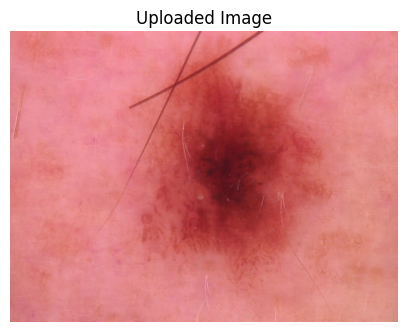

In [37]:
img = Image.open(image_path)

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.axis("off")

plt.title("Uploaded Image")

plt.show()

ADJUSTMENTS

In [41]:
print("MAX_LEN =", MAX_LEN)
print("BiLSTM Input Shape =", bilstm_model.input_shape)

MAX_LEN = 10
BiLSTM Input Shape = (None, 60)


In [42]:
MAX_LEN = 60

In [44]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def extract_text_features(text):

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(
        seq,
        maxlen=60,      # <-- fixed
        padding="post",
        truncating="post"
    )

    features = text_feature_extractor.predict(
        pad,
        verbose=0
    )

    return features

In [45]:
with open(os.path.join(SAVE_DIR, "max_len.pkl"), "rb") as f:
    print(pickle.load(f))

10


In [46]:
MAX_LEN = bilstm_model.input_shape[1]
print("Using MAX_LEN =", MAX_LEN)

Using MAX_LEN = 60


In [47]:
print("Loaded MAX_LEN:", MAX_LEN)
print("BiLSTM Input Shape:", bilstm_model.input_shape)

seq = tokenizer.texts_to_sequences([clinical_note])
print("Sequence Length:", len(seq[0]))

Loaded MAX_LEN: 60
BiLSTM Input Shape: (None, 60)
Sequence Length: 15


In [48]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def extract_text_features(text):

    seq = tokenizer.texts_to_sequences([text])

    pad = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    print("Padded shape:", pad.shape)   # Debug

    features = text_feature_extractor.predict(
        pad,
        verbose=0
    )

    return features

In [49]:
seq = tokenizer.texts_to_sequences([clinical_note])

pad = pad_sequences(
    seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("MAX_LEN:", MAX_LEN)
print("Pad shape:", pad.shape)
print(pad)

MAX_LEN: 60
Pad shape: (1, 60)
[[  3   1 148   1   1  32   1 128   5   1   1 154   1   1 102   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]]


In [50]:
print(text_feature_extractor.input_shape)
print(text_feature_extractor.output_shape)

(None, 60)
(None, 64)


In [51]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def extract_text_features(text):

    seq = tokenizer.texts_to_sequences([text])

    print("Tokenized:", seq)
    print("Token length:", len(seq[0]))

    pad = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    print("Padded shape:", pad.shape)
    print("Padded array:", pad)

    features = text_feature_extractor.predict(
        pad,
        verbose=0
    )

    return features

In [52]:
text_features = extract_text_features(clinical_note)

Tokenized: [[3, 1, 148, 1, 1, 32, 1, 128, 5, 1, 1, 154, 1, 1, 102]]
Token length: 15
Padded shape: (1, 60)
Padded array: [[  3   1 148   1   1  32   1 128   5   1   1 154   1   1 102   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]]


# **Generate Features**

In [53]:
image_features = extract_image_features(image_path)

text_features = extract_text_features(clinical_note)

print(image_features.shape)

print(text_features.shape)

Tokenized: [[3, 1, 148, 1, 1, 32, 1, 128, 5, 1, 1, 154, 1, 1, 102]]
Token length: 15
Padded shape: (1, 60)
Padded array: [[  3   1 148   1   1  32   1 128   5   1   1 154   1   1 102   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]]
(1, 256)
(1, 64)


# **Combine Features**

In [54]:
fusion_features = np.concatenate(

    [image_features, text_features],

    axis=1
)

print(fusion_features.shape)

(1, 320)


# **Predict Disease**

In [62]:
pred = fusion_model.predict(fusion_features, verbose=0)[0]

pred_idx = np.argmax(pred)

confidence = pred[pred_idx]

disease = class_names[pred_idx]

# **Top-3 Predictions**

In [63]:
import pandas as pd

results = pd.DataFrame({
    "Disease": class_names,
    "Probability": pred
})

results = results.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

results["Confidence"] = (
    results["Probability"]*100
).round(2)

results

,Disease,Probability,Confidence
0,df,0.356218,35.619999
1,vasc,0.189107,18.910000
2,akiec,0.164163,16.420000
3,mel,0.134653,13.470000
4,bcc,0.071473,7.150000
5,nv,0.061809,6.180000
6,bkl,0.022577,2.260000


# **Probability Chart**

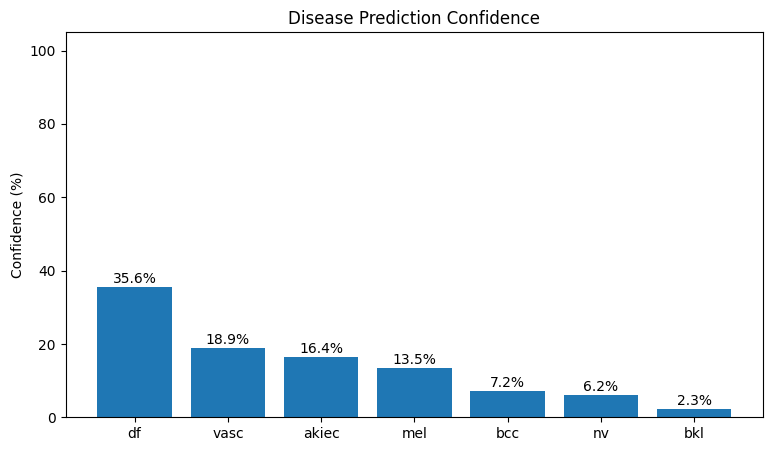

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.bar(
    results["Disease"],
    results["Confidence"]
)

plt.ylabel("Confidence (%)")
plt.title("Disease Prediction Confidence")

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+1,
        f"{h:.1f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0,105)

plt.show()

# **AI Tele-Triage Report**

In [65]:
info = recommendations[disease]

print("="*70)
print("               AI TELE-TRIAGE SYSTEM")
print("="*70)

print("\nPatient Summary")
print("-"*70)

print(f"Age              : {age}")
print(f"Sex              : {sex}")
print(f"Occupation       : {occupation}")
print(f"Lesion Location  : {location}")

print("\nSymptoms")
print("-"*70)

print(symptoms)

print("\nPrediction Result")
print("-"*70)

print(f"Disease          : {info['name']}")
print(f"Short Code       : {disease}")
print(f"Confidence       : {confidence*100:.2f}%")
print(f"Risk Level       : {info['risk']}")

print("\nTop 3 Predictions")
print("-"*70)

for i in range(3):

    row = results.iloc[i]

    full_name = recommendations[row["Disease"]]["name"]

    print(f"{i+1}. {full_name:<35} {row['Confidence']:.2f}%")

print("\nMedical Recommendation")
print("-"*70)

for advice in info["advice"]:

    print(f"✓ {advice}")

print("\nDisclaimer")
print("-"*70)

print("This AI system is intended for preliminary screening only.")
print("Please consult a certified dermatologist for diagnosis.")

print("="*70)

               AI TELE-TRIAGE SYSTEM

Patient Summary
----------------------------------------------------------------------
Age              : 25
Sex              : male
Occupation       : teacher
Lesion Location  : neck

Symptoms
----------------------------------------------------------------------
itching

Prediction Result
----------------------------------------------------------------------
Disease          : Dermatofibroma
Short Code       : df
Confidence       : 35.62%
Risk Level       : Low

Top 3 Predictions
----------------------------------------------------------------------
1. Dermatofibroma                      35.62%
2. Vascular Lesion                     18.91%
3. Actinic Keratoses                   16.42%

Medical Recommendation
----------------------------------------------------------------------
✓ Generally harmless.
✓ No immediate treatment required.
✓ Consult a dermatologist if painful.

Disclaimer
----------------------------------------------------------------

In [68]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("AI_TeleTriage_Report.pdf")

story = []

story.append(Paragraph("<b>AI TELE-TRIAGE REPORT</b>", styles["Title"]))

story.append(Paragraph(f"<b>Disease:</b> {info['name']}", styles["BodyText"]))

story.append(Paragraph(f"<b>Confidence:</b> {confidence*100:.2f}%", styles["BodyText"]))

story.append(Paragraph(f"<b>Risk:</b> {info['risk']}", styles["BodyText"]))

story.append(Paragraph("<b>Recommendations</b>", styles["Heading2"]))

for advice in info["advice"]:
    story.append(Paragraph("• "+advice, styles["BodyText"]))

story.append(Paragraph("<br/>This report is generated by the AI Tele-Triage System and is intended only for preliminary screening.", styles["Italic"]))

doc.build(story)

print("✅ Report saved as AI_TeleTriage_Report.pdf")

✅ Report saved as AI_TeleTriage_Report.pdf


# **Save the Final Fusion Model**

In [69]:
fusion_model.save(
    "/content/drive/MyDrive/AI-TeleTriage-System/models/fusion_final.keras"
)

print("Fusion model saved.")

Fusion model saved.


# **Save Class Names**

In [70]:
import pickle

with open(
    "/content/drive/MyDrive/AI-TeleTriage-System/saved_objects/fusion_class_names.pkl",
    "wb"
) as f:
    pickle.dump(class_names, f)

print("Class names saved.")

Class names saved.


# **Save Recommendation Dictionary**

In [71]:
import pickle

with open(
    "/content/drive/MyDrive/AI-TeleTriage-System/saved_objects/recommendations.pkl",
    "wb"
) as f:
    pickle.dump(recommendations, f)

print("Recommendations saved.")

Recommendations saved.


# **Save Image Size**

In [72]:
IMG_SIZE = (128,128)

with open(
    "/content/drive/MyDrive/AI-TeleTriage-System/saved_objects/image_size.pkl",
    "wb"
) as f:
    pickle.dump(IMG_SIZE,f)

# **Save Clinical Note Template**

In [73]:
clinical_template = """
Patient age {age} years.
Sex {sex}.
Occupation {occupation}.
Lesion located on {location}.
Symptoms include {symptoms}.
"""

with open(
    "/content/drive/MyDrive/AI-TeleTriage-System/saved_objects/template.pkl",
    "wb"
) as f:
    pickle.dump(clinical_template,f)

# **Save Version Information**

In [74]:
import json

info = {
    "cnn":"DenseNet121",
    "text_model":"BiLSTM",
    "fusion":"Feature Fusion",
    "image_size":128,
    "max_len":MAX_LEN,
    "classes":class_names
}

with open(
    "/content/drive/MyDrive/AI-TeleTriage-System/model_info.json",
    "w"
) as f:
    json.dump(info,f,indent=4)

# **Save Final Prediction Example**

In [75]:
example = {
    "age":age,
    "sex":sex,
    "location":location,
    "occupation":occupation,
    "symptoms":symptoms,
    "prediction":disease,
    "confidence":float(confidence)
}

with open(
    "/content/drive/MyDrive/AI-TeleTriage-System/example_prediction.json",
    "w"
) as f:
    json.dump(example,f,indent=4)